In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

print(' Imports OK')

 Imports OK


In [2]:
df = pd.read_csv('../data/listings.csv')

print(f'Shape : {df.shape}')
df.head()


Shape : (84055, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3109,https://www.airbnb.com/rooms/3109,20250606142312,2025-06-20,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,https://www.airbnb.com/users/show/3631,Anne,2008-10-14,"Paris, France",NaN,within an hour,100%,100%,f,https://a0.muscache.com/im/users/3631/profile_...,https://a0.muscache.com/im/users/3631/profile_...,Alésia,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Observatoire,NaN,48.83191,2.31870,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Kitchen"", ""Dishes and silverware"", ""Self che...",$135.00,2,30,2,2,30,30,2.0,30.0,NaN,t,20,50,80,355,2025-06-20,7,3,1,185,0,31,4185.0,2017-10-28,2025-06-03,5.00,5.00,5.00,5.00,5.00,5.00,5.00,7511409139079,f,1,1,0,0,0.08
1,5396,https://www.airbnb.com/rooms/5396,20250606142312,2025-06-19,city scrape,Your perfect Paris studio on Île Saint-Louis,"Cozy, well-appointed and graciously designed s...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,https://www.airbnb.com/users/show/7903,Borzou,2009-02-14,"Paris, France",We have spent a lot of time traveling for work...,within an hour,100%,95%,f,https://a0.muscache.com/im/users/7903/profile_...,https://a0.muscache.com/im/users/7903/profile_...,Saint-Paul - Ile Saint-Louis,2.0,4.0,"['email', 'phone']",t,t,Neighborhood highlights,Hôtel-de-Ville,NaN,48.85247,2.35835,Entire rental unit,Entire home/apt,2,1.0,1 bath,0.0,1.0,"[""Shampoo"", ""Long term stays allowed"", ""Portab...",$114.00,1,730,1,1,1125,1125,1.0,1125.0,NaN,t,7,37,54,69,2025-06-19,452,48,4,69,52,255,29070.0,2009-06-30,2025-06-05,4.62,4.64,4.59,4.81,4.85,4.95,4.59,7510402838018,f,1,1,0,0,2.32
2,7397,https://www.airbnb.com/rooms/7397,20250606142312,2025-06-20,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,https://www.airbnb.com/users/show/2626,Franck,2008-08-30,"Paris, France","I am a writer,54, author of novels, books of l...",within an hour,100%,67%,t,https://a0.muscache.com/im/pictures/user/ad6a9...,https://a0.muscache.com/im/pictures/user/ad6a9...,Le Marais,1.0,10.0,"['email', 'phone']",t,t,NaN,Hôtel-de-Ville,NaN,48.85909,2.35315,Entire rental unit,Entire home/apt,4,1.0,1 bath,2.0,1.0,"[""Shampoo"", ""Oven"", ""Microwave"", ""Hair dryer"",...",$149.00,10,130,1,10,130,130,9.6,130.0,NaN,t,0,12,27,197,2025-06-20,380,25,2,122,24,255,37995.0,2011-04-08,2025-06-03,4.73,4.80,4.45,4.92,4.89,4.

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84055 entries, 0 to 84054
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            84055 non-null  int64  
 1   listing_url                                   84055 non-null  object 
 2   scrape_id                                     84055 non-null  int64  
 3   last_scraped                                  84055 non-null  object 
 4   source                                        84055 non-null  object 
 5   name                                          84055 non-null  object 
 6   description                                   81177 non-null  object 
 7   neighborhood_overview                         41178 non-null  object 
 8   picture_url                                   84054 non-null  object 
 9   host_id                                       84055 non-null 

In [4]:
# Nettoyage de la colonne price
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print(df['price'].head())
print(df['price'].dtype)

0    135.0
1    114.0
2    149.0
3      NaN
4     75.0
Name: price, dtype: float64
float64


In [5]:
na_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

na_df = pd.DataFrame({
    'missing_%': na_percent
})

na_df.head(20)

,missing_%
neighbourhood_group_cleansed,100.000000
calendar_updated,100.000000
host_neighbourhood,65.599905
host_about,55.495806
neighbourhood,51.010648
neighborhood_overview,51.010648
host_response_rate,37.346975
host_response_time,37.346975
estimated_revenue_l365d,35.800369
price,35.800369


In [6]:
cols_to_drop = [
    'id',
    'listing_url',
    'scrape_id',
    'last_scraped',
    'picture_url',
    'host_url',
    'host_thumbnail_url',
    'host_picture_url',
    'calendar_updated',
    'neighbourhood_group_cleansed',
    'license',
    'name',
    'description',
    'neighborhood_overview',
    'host_about'
]

df = df.drop(columns=cols_to_drop)

print(df.shape)

(84055, 64)


In [7]:
df = df.dropna(subset=['price'])

print(df.shape)

(53963, 64)


In [8]:
df['has_wifi'] = df['amenities'].str.contains('Wifi', case=False, na=False).astype(int)

df['has_tv'] = df['amenities'].str.contains('TV', case=False, na=False).astype(int)

df['has_kitchen'] = df['amenities'].str.contains('Kitchen', case=False, na=False).astype(int)

df['has_air_conditioning'] = df['amenities'].str.contains('Air conditioning', case=False, na=False).astype(int)

df['has_pool'] = df['amenities'].str.contains('Pool', case=False, na=False).astype(int)

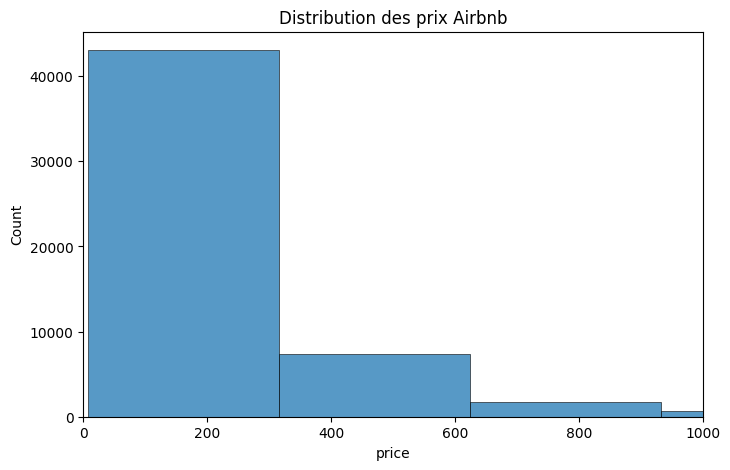

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=100)

plt.title('Distribution des prix Airbnb')
plt.xlim(0, 1000)

plt.show()

Montrer le problème de skewness

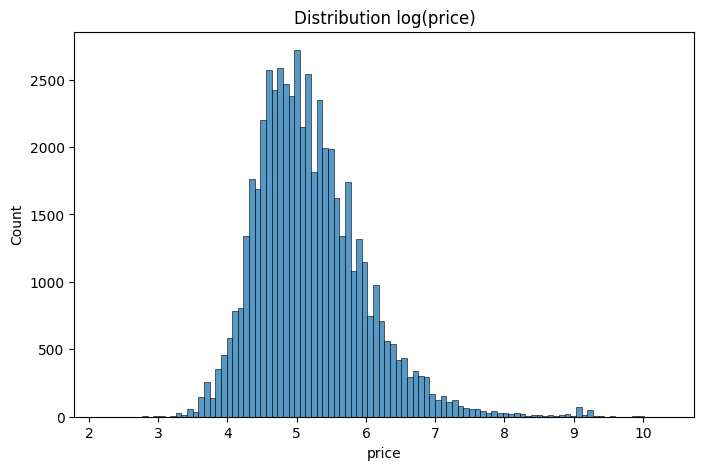

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df['price']), bins=100)

plt.title('Distribution log(price)')
plt.show()

"""
Observations :

- La distribution du prix est fortement asymétrique à droite.
- Quelques logements de luxe créent des outliers très élevés.
- Une transformation logarithmique semble nécessaire.
- Les équipements comme Wifi et climatisation semblent fréquents.
- Beaucoup de valeurs manquantes existent dans les reviews et informations host.
"""

ÉTAPE 9 — Choisir les features

IMPORTANT : ne prends PAS les 70 colonnes sinon ça devient ingérable.

Prends une sélection propre.

In [11]:
selected_features = [
    'host_response_rate',
    'host_acceptance_rate',
    'host_is_superhost',
    'neighbourhood_cleansed',
    'property_type',
    'room_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'availability_365',

    # amenities
    'has_wifi',
    'has_tv',
    'has_kitchen',
    'has_air_conditioning',
    'has_pool'
]

X = df[selected_features].copy()
y = df['price']

ÉTAPE 10 — Nettoyer les %

Ces colonnes sont encore en string :

100%

Il faut convertir.

In [12]:
for col in ['host_response_rate', 'host_acceptance_rate']:

    X[col] = (
        X[col]
        .astype(str)
        .str.replace('%', '', regex=False)
    )

    X[col] = pd.to_numeric(X[col], errors='coerce')

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_test.shape)

(43170, 20)
(10793, 20)


In [15]:
num_cols = [
    'host_response_rate',
    'host_acceptance_rate',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'availability_365'
]

cat_cols = [
    'host_is_superhost',
    'neighbourhood_cleansed',
    'property_type',
    'room_type'
]

amenities_cols = [
    'has_wifi',
    'has_tv',
    'has_kitchen',
    'has_air_conditioning',
    'has_pool'
]

In [16]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols),

    ('amenities', 'passthrough', amenities_cols)
])

In [17]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'RandomForest': RandomForestRegressor(
        random_state=RANDOM_STATE
    )
}

In [ ]:
from sklearn.compose import TransformedTargetRegressor
results = []

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=model,
            func=np.log1p,
            inverse_func=np.expm1
        ))
    ])

    mae_scores = -cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_mean_absolute_error'
    )

    r2_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=kf,
        scoring='r2'
    )

    results.append({
        'Model': name,
        'MAE mean': mae_scores.mean(),
        'MAE std': mae_scores.std(),
        'R2 mean': r2_scores.mean(),
        'R2 std': r2_scores.std()
    })

results_df = pd.DataFrame(results)

results_df